# Learning to make a market with mbt_gym and Stable Baselines 3

论文最核心的 RL 学习实验，最接近论文 Section 4 。

它做的流程基本是：

构建一个 Cartea–Jaimungal 风格的 market making 环境；

用 StableBaselines3 里的 PPO 训练；

用较大的并行 rollout 数做向量化训练；

训练完后，把 PPO 学到的 bid/ask depth 随 inventory 的变化，
和 CarteaJaimungalMmAgent 的解析最优策略做比较。

这正对应论文里两张关键图：

Figure 2：不同向量化程度下的训练效果；

Figure 3：learned PPO policy vs CarteaJaimungalAgent。

也就是说，你如果想看“论文实验代码到底在哪”，答案基本就是：

Learning_to_make_a_market_with_mbt_gym_and_Stable_Baselines_3.ipynb 是正文主实验；
Test_2 是它的理论基准验证；
Test_1 和 Baseline_Agents 是环境/解析 agent 的补充验证和展示。

### Import external modules

In [1]:
import gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

2026-03-17 06:17:55.668585: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 06:17:55.953283: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 06:17:55.953417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 06:17:56.002035: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 06:17:56.097350: I tensorflow/core/platform/cpu_feature_guar

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
terminal_time = 1.0
arrival_rate = 10.0
n_steps = int(10 * terminal_time * arrival_rate)
phi = 0.5
alpha = 0.001

In [1]:
from typing import Literal


from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics


from mbt_gym.rewards.RewardFunctions import CjMmCriterion


def get_cj_env(num_trajectories:int = 1):
    fill_exponent = 1 # 成交概率的指数模型参数
    sigma = 0.1 # 中间价布朗运动的波动率
    initial_inventory = (-4,5) # 库存区间
    initial_price = 100 # 初始价格
    step_size = 1/n_steps # 时间离散
    timestamps = np.linspace(0, terminal_time, n_steps + 1) # 时间离散
    midprice_model = BrownianMotionMidpriceModel(volatility=sigma, step_size=1/n_steps,
                                                 num_trajectories=num_trajectories) # 中间价模型
    arrival_model = PoissonArrivalModel(intensity=np.array([arrival_rate, arrival_rate]), 
                                        step_size=1/n_steps, 
                                        num_trajectories=num_trajectories) # 到达过程
    fill_probability_model = ExponentialFillFunction(fill_exponent=fill_exponent, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories) # 成交概率
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories) # 环境
    reward_function = CjMmCriterion(per_step_inventory_aversion = phi, terminal_inventory_aversion = alpha) # 奖励函数
    env_params = dict[str, float | tuple[Literal[-4], Literal[5]] | LimitOrderModelDynamics | CjMmCriterion](terminal_time=terminal_time, 
                      n_steps=n_steps,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      reward_function = reward_function,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

ModuleNotFoundError: No module named 'mbt_gym'

In [ ]:
num_trajectories = 1000
env = ReduceStateSizeWrapper(get_cj_env(num_trajectories)) 
# 拿到Cartea–Jaimungal环境，并压缩，压缩掉inventory和time外的其他维度，如现金、midprice、arrival、fill probability
# 为了在最后的图上体现库存-derta规律，这里免掉time维度

sb_env = StableBaselinesTradingEnvironment(trading_env=env)  

In [ ]:
# Monitor sb_env
sb_env = VecMonitor(sb_env) # 环境vec是隐式的，采样过程需要记录，监控
# Add directory for tensorboard logging and best model
tensorboard_logdir = "./tensorboard/PPO-learning-CJ/" # 日志目录
best_model_path = "./SB_models/PPO-best-CJ" # 最佳模型目录

### 研究一下这个环境的状态空间，动作空间，step函数，reset函数

状态空间：由 cash、inventory、time 三个基础状态 + 各随机过程的状态拼接而成（包括 midprice、arrival、fill_probability 等）
step函数：先把动作反归一化 → 取当前状态 → 更新状态 → 计算终止 → 计算奖励与 info → 返回观测、奖励、done、info
动作空间：
reset函数：重置所有随机过程、状态、奖励函数，并返回归一化后的初始观测


### Define PPO policy

In [ ]:
policy_kwargs = dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])]) 
# 定义策略网络和价值网络的结构，两层，每层256个神经元
PPO_params = {"policy":'MlpPolicy', "env": sb_env, "verbose":1, 
              "policy_kwargs":policy_kwargs, 
              "tensorboard_log":tensorboard_logdir,
              "n_epochs":3,
              "batch_size": int(n_steps * num_trajectories / 10), 
              "n_steps": int(n_steps)}
# 使用 MLP神经网络策略，verbose打印训练日志，tensorboard_log用tensorboard画训练曲线，n_epochs：PPO每轮更新重复训练3次，n_steps每个rollout的长度，
# batch_size：每次梯度更新使用的数据量，
callback_params = dict(eval_env=sb_env, n_eval_episodes = 2048, #200 before  (n_eval_episodes)
                       best_model_save_path = best_model_path, 
                       deterministic=True)

callback = EvalCallback(**callback_params) # 实例化评估回调模型
# 相当于验证集，每隔一段训练时间，暂停，跑2048个episode，计算平均reward，如果表现更好就保存模型
model = PPO(**PPO_params, device="cuda")

Using cuda device


/opt/conda/envs/RL2/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(
/opt/conda/envs/RL2/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [10]:
model.learn(total_timesteps = 10_000_000)  # Increase number of training timesteps according to computing resources

Logging to ./tensorboard/PPO-learning-CJ/PPO_3
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -4.17    |
| time/              |          |
|    fps             | 118377   |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 100000   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 100          |
|    ep_rew_mean          | -5.97        |
| time/                   |              |
|    fps                  | 111441       |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 200000       |
| train/                  |              |
|    approx_kl            | 0.0022111593 |
|    clip_fraction        | 0.00502      |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explai

## Comparing the learnt policy to the optimal policy

In [11]:
from mbt_gym.agents.SbAgent import SbAgent

In [ ]:
ppo_agent = SbAgent(model)
# 将stable的agent包装成mbt环境的agent，因为接收的接口不一致

In [ ]:
import numpy as np
inventories = np.arange(-3,4,1)
# a=np.array([[inventory,0.5]])

In [ ]:
# 统一输入进行比较
inventories = np.arange(-3,4,1)
bid_actions = []
ask_actions = []
for inventory in inventories:
    bid_action, ask_action = ppo_agent.get_action(np.array([[inventory,0.5]])).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)

In [ ]:
#ppo_agent.get_action(np.array([[inventory,0.5]]))

In [ ]:
cj_agent = CarteaJaimungalMmAgent(env=get_cj_env()) # 直接得到一个理论最优模型策略

In [ ]:
# Get the Cartea Jaimungal action
cj_bid_actions = []
cj_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = cj_agent.get_action(np.array([[0,inventory,0.5]])).reshape(-1) # [0,inventory,0.5]为[time, inventory, price]
    # 最后的图要体现库存-derta规律，ppo可以忽略掉时间维度，理论模型没法忽略就做切片
    cj_bid_actions.append(bid_action)
    cj_ask_actions.append(ask_action)
# 计算不同库存下，理论最优模型的bid，ask报价
# 问题：自变量本来是(t,s,q,x)，为什么只剩下了q？
# 因为：CJ模型有两个关键性质：1.价格是平移不变的，所以s固定；2.x不影响最优控制。最后固定t=0，变量只有q了。

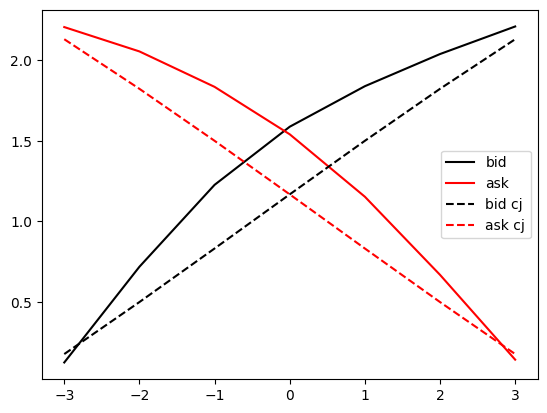

In [16]:
plt.plot(inventories, bid_actions, label = "bid", color = "k")
plt.plot(inventories, ask_actions, label = "ask", color = "r")
plt.plot(inventories, cj_bid_actions, label = "bid cj", color = "k", linestyle = "--")
plt.plot(inventories, cj_ask_actions, label = "ask cj", color = "r", linestyle = "--")
plt.legend()